# 1.3 — Shot Maps

El Clásico, La Liga 2020/21: Barcelona 1-3 Real Madrid.
We build a shot map step by step: raw locations → xG sizing → outcome coloring → side-by-side normalized view.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('/Users/stefanhofmann/Documents/Bewerbung/Portfolio/Blog/assets/helpers')
from data_loader import load_competitions, load_matches, load_events, flatten_events
from pitch import draw_pitch

FIGURES = 'figures'

---
## Load the Match

In [2]:
MATCH_ID = 3773585

comp_df = load_competitions()
row = comp_df[
    (comp_df['competition_name'] == 'La Liga') &
    (comp_df['season_name'] == '2020/2021')
].iloc[0]

matches = load_matches(row['competition_id'], row['season_id'])
match_row = matches[matches['match_id'] == MATCH_ID].iloc[0]

home_team = match_row['home_team']['home_team_name']
away_team  = match_row['away_team']['away_team_name']

print(f'{home_team} {match_row["home_score"]}-{match_row["away_score"]} {away_team}')

Barcelona 1-3 Real Madrid


---
## Extract Shots

In [3]:
raw = load_events(MATCH_ID)
df  = flatten_events(raw)

shots = df[df['type'] == 'Shot'].copy()
print(f'Total shots: {len(shots)}')
shots[['team', 'player', 'x', 'y', 'shot_statsbomb_xg', 'shot_outcome']].head(8)

Total shots: 26


,team,player,x,y,shot_statsbomb_xg,shot_outcome
288,Real Madrid,Federico Santiago Valverde Dipetta,109.9,49.3,0.312147,Goal
362,Real Madrid,Vinícius José Paixão de Oliveira Júnior,107.6,37.9,0.142474,Off T
390,Barcelona,Anssumane Fati,114.8,36.5,0.395557,Goal
564,Barcelona,Philippe Coutinho Correia,97.5,22.1,0.012288,Blocked
681,Barcelona,Philippe Coutinho Correia,97.3,30.5,0.047765,Saved
907,Barcelona,Lionel Andrés Messi Cuccittini,94.3,31.8,0.037000,Saved
987,Real Madrid,Raphaël Varane,113.6,37.8,0.108191,Blocked
995,Real Madrid,Sergio Ramos García,113.2,36.5,0.102100,Saved


---
## xG Summary by Team

In [4]:
summary = shots.groupby('team').agg(
    shots=('x', 'count'),
    xG=('shot_statsbomb_xg', 'sum'),
    goals=('shot_outcome', lambda x: (x == 'Goal').sum())
).round(2)
print(summary)

             shots    xG  goals
team                           
Barcelona       10  1.25      1
Real Madrid     16  2.90      3


---
## Step 1: Raw Shot Locations

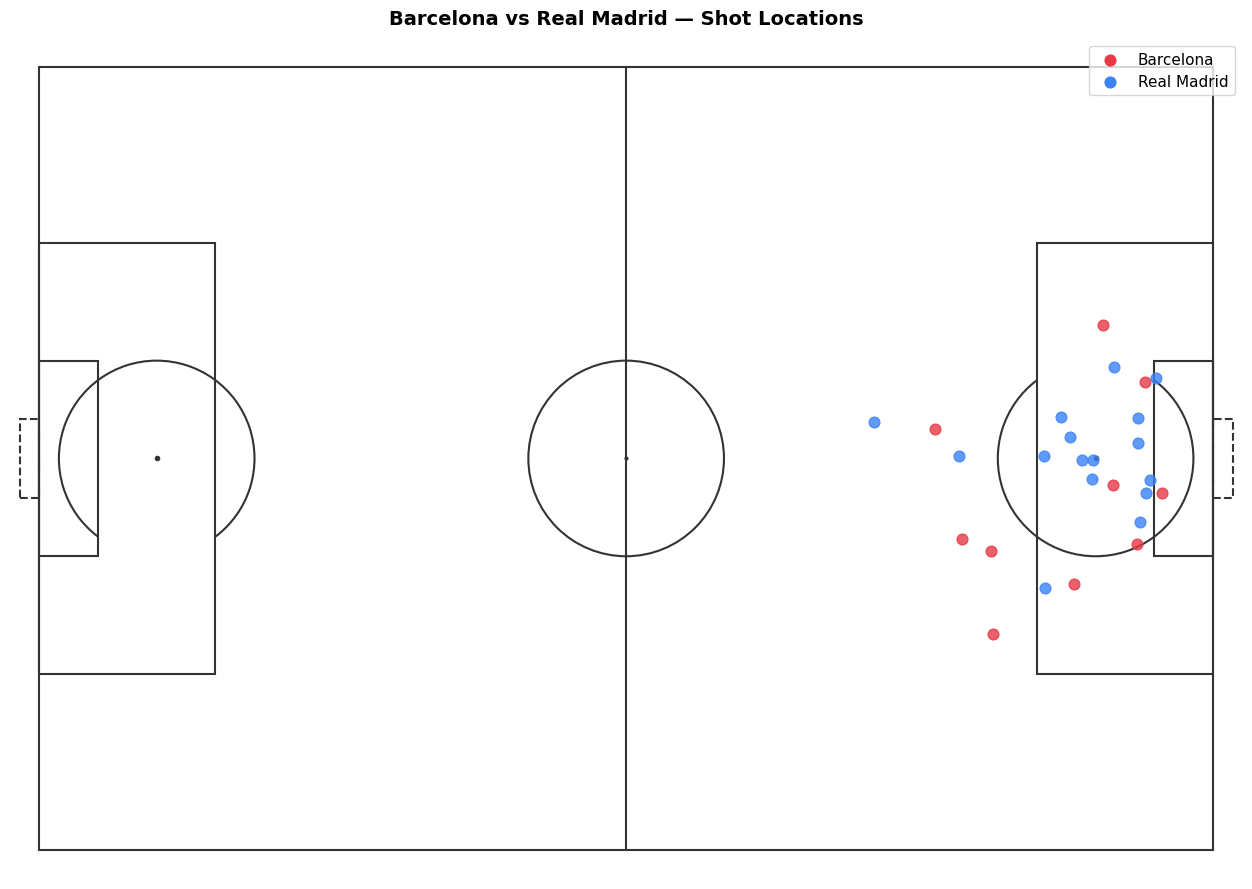

In [5]:
fig, ax = plt.subplots(figsize=(14, 9))
draw_pitch(ax, color='white', line_color='#333333')

for _, shot in shots.iterrows():
    color = '#e63946' if shot['team'] == home_team else '#3b82f6'
    ax.scatter(shot['x'], shot['y'], color=color, s=60, zorder=5, alpha=0.8)

ax.scatter([], [], color='#e63946', s=60, label=home_team)
ax.scatter([], [], color='#3b82f6', s=60, label=away_team)
ax.legend(loc='upper right', fontsize=11)

ax.set_title(f'{home_team} vs {away_team} — Shot Locations', fontweight='bold', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig(f'{FIGURES}/shots_raw.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2: xG as Size, Outcome as Fill

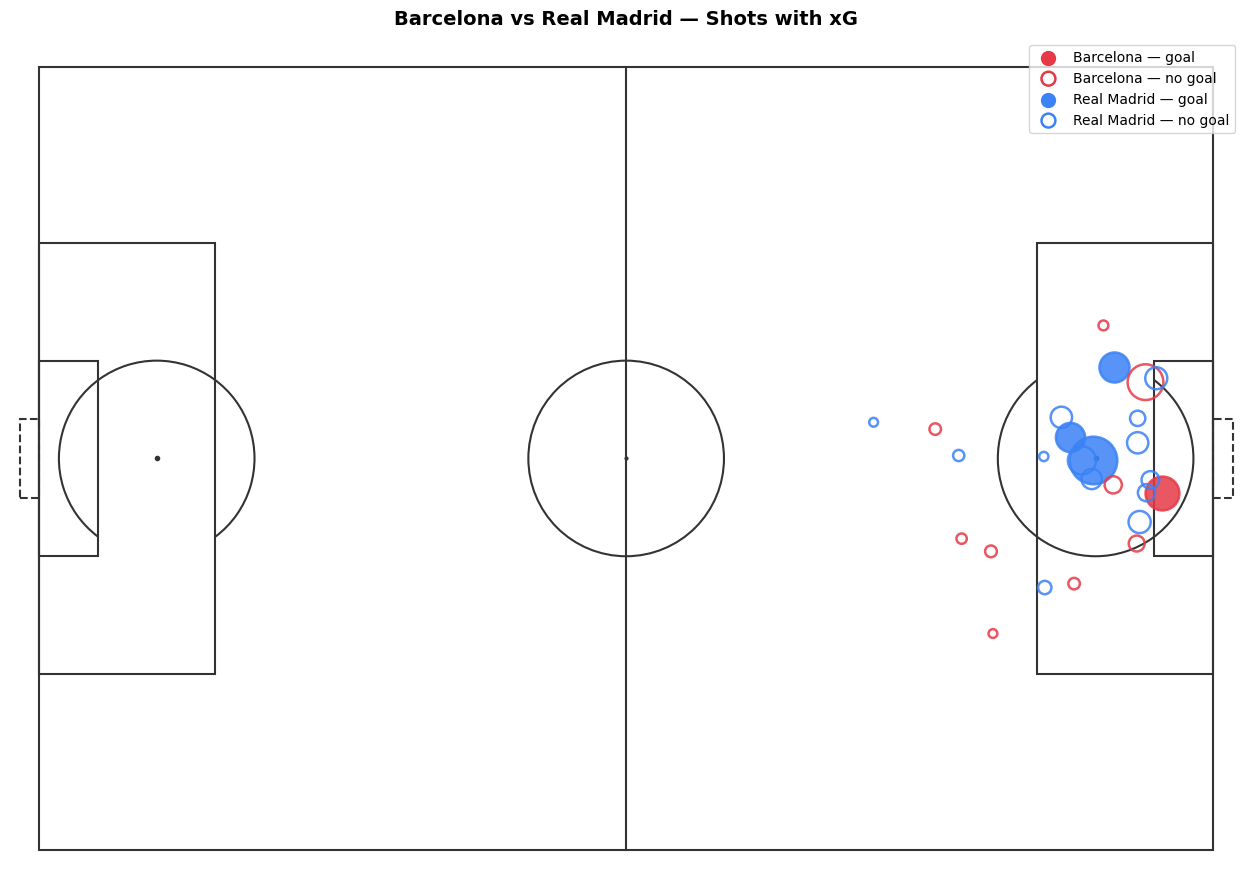

In [6]:
fig, ax = plt.subplots(figsize=(14, 9))
draw_pitch(ax, color='white', line_color='#333333')

for _, shot in shots.iterrows():
    color   = '#e63946' if shot['team'] == home_team else '#3b82f6'
    size    = max(shot['shot_statsbomb_xg'] * 1500, 40)
    is_goal = shot['shot_outcome'] == 'Goal'
    ax.scatter(shot['x'], shot['y'],
               s=size,
               color=color if is_goal else 'none',
               edgecolors=color, linewidths=1.8,
               zorder=5, alpha=0.85)

ax.scatter([], [], color='#e63946', s=100, label=f'{home_team} — goal')
ax.scatter([], [], color='none', edgecolors='#e63946', linewidths=1.8, s=100, label=f'{home_team} — no goal')
ax.scatter([], [], color='#3b82f6', s=100, label=f'{away_team} — goal')
ax.scatter([], [], color='none', edgecolors='#3b82f6', linewidths=1.8, s=100, label=f'{away_team} — no goal')
ax.legend(loc='upper right', fontsize=10)

ax.set_title(f'{home_team} vs {away_team} — Shots with xG', fontweight='bold', fontsize=14, pad=10)
plt.tight_layout()
plt.savefig(f'{FIGURES}/shots_xg.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 3: Normalize Direction

In [7]:
def normalize_direction(x, y):
    if x < 60:
        return 120 - x, 80 - y
    return x, y

shots[['x_norm', 'y_norm']] = shots.apply(
    lambda r: pd.Series(normalize_direction(r['x'], r['y'])), axis=1
)

---
## Step 4: Side-by-Side Shot Map

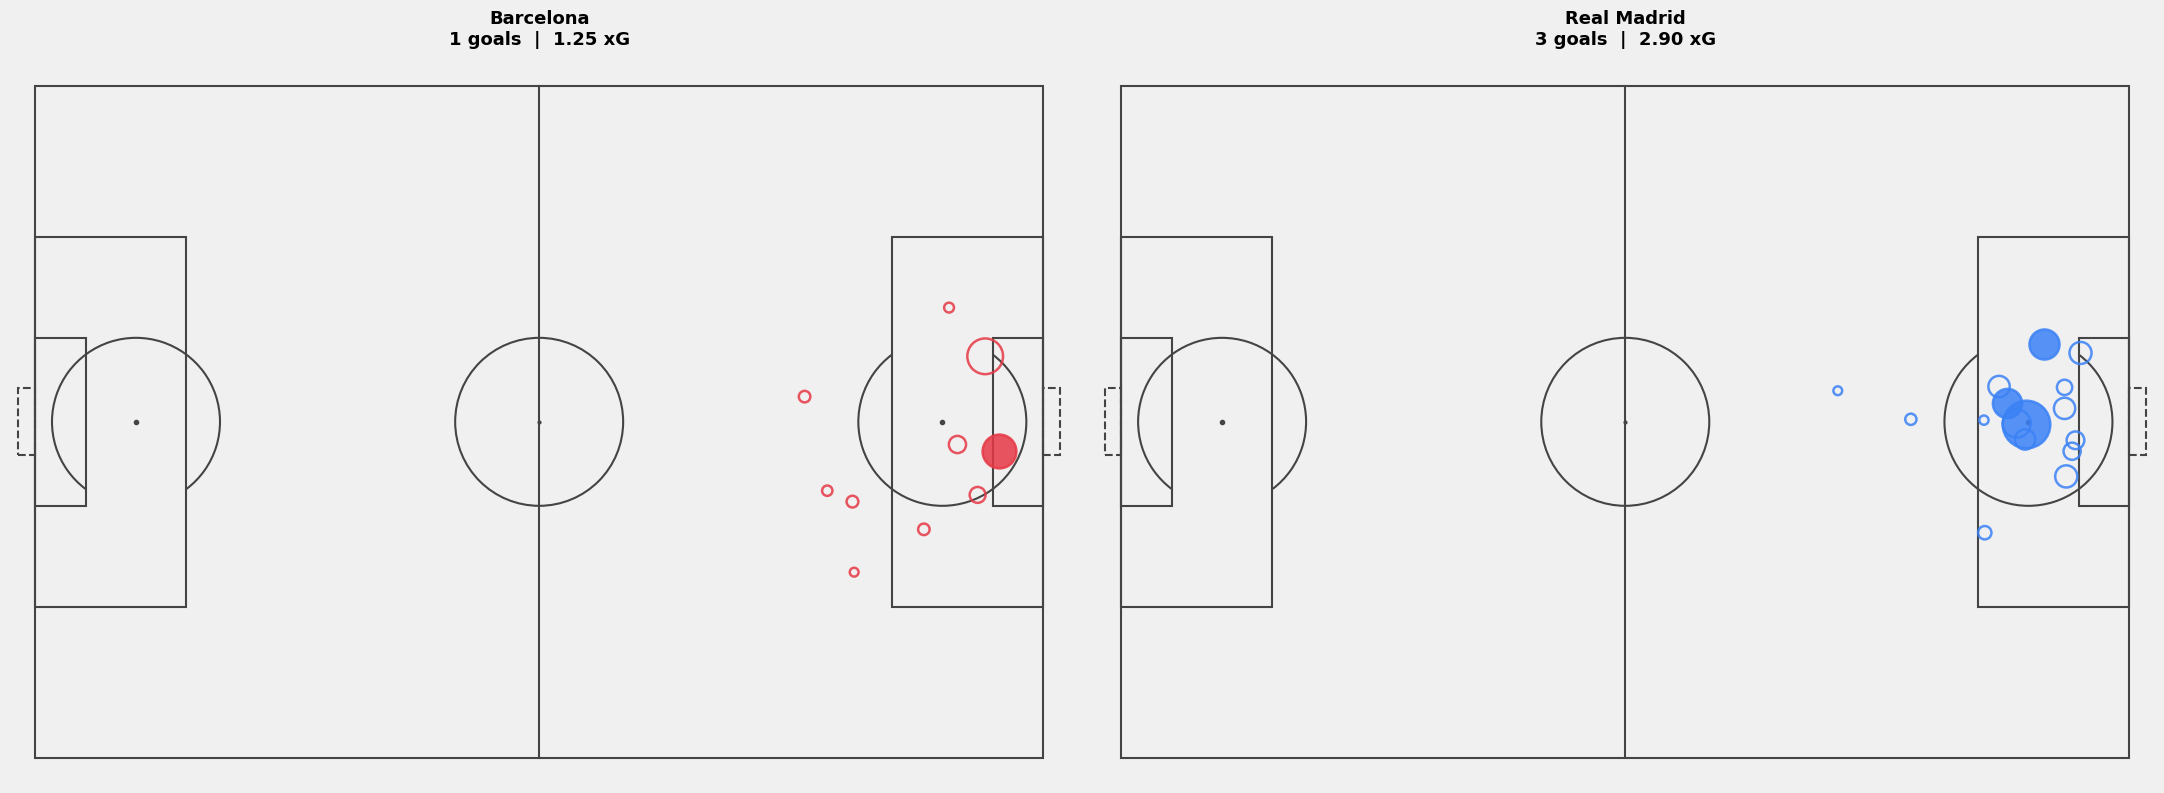

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.patch.set_facecolor('#f0f0f0')

for ax, team, color in zip(axes, [home_team, away_team], ['#e63946', '#3b82f6']):
    draw_pitch(ax, color='white', line_color='#444444')
    team_shots = shots[shots['team'] == team]

    for _, shot in team_shots.iterrows():
        size    = max(shot['shot_statsbomb_xg'] * 1500, 40)
        is_goal = shot['shot_outcome'] == 'Goal'
        ax.scatter(shot['x_norm'], shot['y_norm'],
                   s=size,
                   color=color if is_goal else 'none',
                   edgecolors=color, linewidths=1.8,
                   zorder=5, alpha=0.85)

    total_xg = team_shots['shot_statsbomb_xg'].sum()
    goals     = (team_shots['shot_outcome'] == 'Goal').sum()
    ax.set_title(f'{team}\n{goals} goals  |  {total_xg:.2f} xG',
                 fontweight='bold', fontsize=13, pad=12)

plt.tight_layout(pad=2)
plt.savefig(f'{FIGURES}/shot_map_both.png', dpi=150, bbox_inches='tight')
plt.show()

---
**Next: [1.4 — Pass Networks](../1.4_Pass_Netzwerke/notebook.ipynb)**